In [ ]:
# ==========================================
# 1. SETUP & IMPORTS
# ==========================================
!pip install -q rdkit xgboost torch

import numpy as np
import pandas as pd
import joblib
import os
import requests
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')

# PATHS (Clean Run)
project_folder = '/content/drive/My Drive/JCIM_BACE1_Project_cleaned_2'
if not os.path.exists(project_folder):
    os.makedirs(project_folder)
    print(f"✅ Created Clean Folder: {project_folder}")

bace_filename = "inhibitors_pKi_M_cleaned.txt"

# 2. LOAD QSAR ARTIFACTS
print("--- 1. LOADING QSAR ARTIFACTS ---")
try:
    qsar_model = joblib.load(os.path.join(project_folder, 'final_model_strict.pkl'))
    selector = joblib.load(os.path.join(project_folder, 'feature_selector_strict.pkl'))
    train_idx = np.load(os.path.join(project_folder, 'train_indices.npy'))

    # Load AD ZONES
    ad_zones = joblib.load(os.path.join(project_folder, 'ad_definition_zones.pkl'))
    ZONE_A_TH = ad_zones['zone_definitions']['Zone A (Interpolation)']['threshold']
    ZONE_B_TH = ad_zones['zone_definitions']['Zone B (Extrapolation)']['threshold']

    print(f"✅ QSAR Model Loaded.")
    print(f"✅ AD Zones Loaded: A > {ZONE_A_TH:.3f} | B > {ZONE_B_TH:.3f}")

except FileNotFoundError as e:
    print(f"❌ ERROR: Missing File: {e}")

# 3. PREPARE DATASETS
print("\n--- 2. PREPARING DATASETS ---")

# A. Download Moses
if not os.path.exists("general_chemistry.csv"):
    url = "https://github.com/molecularsets/moses/raw/master/data/train.csv"
    response = requests.get(url, stream=True)
    with open("general_chemistry.csv", "wb") as f:
        for chunk in response.iter_content(chunk_size=1024):
            if chunk: f.write(chunk)
gen_df = pd.read_csv("general_chemistry.csv")

# B. Prepare BACE1
bace_path = os.path.join(project_folder, bace_filename)
if not os.path.exists(bace_path):
    if os.path.exists(bace_filename): bace_path = bace_filename
    else: raise FileNotFoundError(f"⚠️ PLEASE UPLOAD {bace_filename}")

bace_df = pd.read_csv(bace_path, sep='\t')
bace_train_df = bace_df.iloc[train_idx].copy()
print(f"✅ BACE1 Data Filtered: {len(bace_train_df)} molecules")

# 4. BUILD VOCABULARY & LOADERS
print("\n--- 3. BUILDING VOCABULARY ---")

class Vocabulary:
    def __init__(self, smiles_list):
        chars = set("".join(smiles_list))
        self.chars = sorted(list(chars))
        self.vocab_size = len(self.chars) + 3
        self.char_to_idx = {c: i+3 for i, c in enumerate(self.chars)}
        self.char_to_idx['<pad>'] = 0; self.char_to_idx['<sos>'] = 1; self.char_to_idx['<eos>'] = 2
        self.idx_to_char = {v: k for k, v in self.char_to_idx.items()}

    def encode(self, smiles):
        return [self.char_to_idx['<sos>']] + [self.char_to_idx[c] for c in smiles] + [self.char_to_idx['<eos>']]

    def decode(self, indices):
        tokens = []
        for idx in indices:
            if idx == self.char_to_idx['<eos>']: break
            if idx == self.char_to_idx['<sos>']: continue
            if idx == self.char_to_idx['<pad>']: continue
            tokens.append(self.idx_to_char[idx])
        return "".join(tokens)

all_smiles = gen_df['SMILES'].tolist() + bace_train_df['SMILES'].tolist()
vocab = Vocabulary(all_smiles)
print(f"✅ Vocabulary Size: {vocab.vocab_size} characters")

# Create Loaders
class MolDataset(Dataset):
    def __init__(self, smiles_list, vocab):
        self.smiles_list = smiles_list
        self.vocab = vocab
    def __len__(self): return len(self.smiles_list)
    def __getitem__(self, idx): return torch.tensor(self.vocab.encode(self.smiles_list[idx]), dtype=torch.long)

def collate_fn(batch): # Dynamic padding
    lengths = [len(s) for s in batch]; max_len = max(lengths)
    padded = torch.zeros(len(batch), max_len, dtype=torch.long)
    for i, seq in enumerate(batch): padded[i, :len(seq)] = seq
    return padded

gen_loader = DataLoader(MolDataset(gen_df['SMILES'].tolist(), vocab), batch_size=128, shuffle=True, collate_fn=collate_fn)
bace_loader = DataLoader(MolDataset(bace_train_df['SMILES'].tolist(), vocab), batch_size=32, shuffle=True, collate_fn=collate_fn)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("✅ Block 1 Complete.")

Mounted at /content/drive
--- 1. LOADING QSAR ARTIFACTS ---
✅ QSAR Model Loaded.
✅ AD Zones Loaded: A > 0.694 | B > 0.529

--- 2. PREPARING DATASETS ---
✅ BACE1 Data Filtered: 1777 molecules

--- 3. BUILDING VOCABULARY ---
✅ Vocabulary Size: 33 characters
✅ Block 1 Complete.


In [ ]:
# ==========================================
# 3. DEFINE THE LSTM MODEL
# ==========================================
import torch.nn as nn
import torch.nn.functional as F

class MolecularLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size=128, hidden_size=512, num_layers=3, dropout=0.2):
        super(MolecularLSTM, self).__init__()
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # 1. Embedding Layer: Converts indices (e.g., 5) to vectors
        self.embedding = nn.Embedding(vocab_size, embed_size)

        # 2. LSTM Layers: The "Memory"
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout)

        # 3. Output Layer: Predicts the next character
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        # x shape: (batch_size, sequence_length)
        embeds = self.embedding(x)
        output, hidden = self.lstm(embeds, hidden)
        # output shape: (batch, seq_len, hidden) -> (batch, seq_len, vocab)
        logits = self.fc(output)
        return logits, hidden

    def sample(self, vocab, max_len=100, temp=1.0, device='cuda'):
        """
        Generates a new molecule character-by-character.
        """
        self.eval() # Switch to evaluation mode
        # Start with <sos> token
        current_idx = torch.tensor([[vocab.char_to_idx['<sos>']]], device=device)
        hidden = None
        smi_indices = []

        with torch.no_grad():
            for _ in range(max_len):
                logits, hidden = self.forward(current_idx, hidden)
                # Apply temperature (Higher temp = more random/creative)
                probs = F.softmax(logits[:, -1, :] / temp, dim=-1)

                # Sample from the distribution
                next_idx = torch.multinomial(probs, 1)

                idx_val = next_idx.item()
                if idx_val == vocab.char_to_idx['<eos>']:
                    break

                smi_indices.append(idx_val)
                current_idx = next_idx

        return vocab.decode(smi_indices)

# Initialize the Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MolecularLSTM(vocab.vocab_size).to(device)

print(f"✅ Model Initialized on {device}")
print(f"   Architecture: 3-Layer LSTM, 512 Hidden Units")
print(f"   Trainable Parameters: {sum(p.numel() for p in model.parameters()):,}")

✅ Model Initialized on cpu
   Architecture: 3-Layer LSTM, 512 Hidden Units
   Trainable Parameters: 5,538,465


In [ ]:
# ==========================================
# 4. PRE-TRAINING (GRAMMAR) - FIXED
# ==========================================
import time
from rdkit import Chem

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# Ignore <pad> index (0) so the model doesn't cheat by predicting padding
criterion = nn.CrossEntropyLoss(ignore_index=0)

def train_one_epoch(loader, name="General"):
    model.train() # Ensure we start in training mode
    total_loss = 0
    start_time = time.time()

    progress = tqdm(loader, desc=f"Training ({name})")
    for batch_idx, batch in enumerate(progress):
        batch = batch.to(device)

        # Inputs: Everything except last char
        inputs = batch[:, :-1]
        # Targets: Everything except first char (<sos>)
        targets = batch[:, 1:]

        optimizer.zero_grad()
        logits, _ = model(inputs)

        # Reshape for Loss
        loss = criterion(logits.reshape(-1, vocab.vocab_size), targets.reshape(-1))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss += loss.item()
        progress.set_postfix({'loss': loss.item()})

        # Sanity Check every 1000 batches
        if batch_idx % 1000 == 0 and batch_idx > 0:
            samp = model.sample(vocab)
            print(f"\n   Example at step {batch_idx}: {samp}")
            # CRITICAL FIX: Switch back to training mode after sampling!
            model.train()

    print(f"✅ Epoch Complete. Avg Loss: {total_loss / len(loader):.4f}")

# RUN PRE-TRAINING
print("--- STARTING PRE-TRAINING (Learning Syntax) ---")
train_one_epoch(gen_loader, name="Moses_Pretrain")

# TEST: Generate 10 molecules to check validity
print("\n--- VALIDITY CHECK ---")
valid_count = 0
for i in range(10):
    smi = model.sample(vocab)
    mol = Chem.MolFromSmiles(smi)
    status = "VALID" if mol else "INVALID"
    if mol: valid_count += 1
    print(f"{status}: {smi}")

# FIX VALIDITY CHECK
from rdkit import Chem

print("\n--- VALIDITY CHECK ---")
valid_count = 0
for i in range(10):
    smi = model.sample(vocab)
    mol = Chem.MolFromSmiles(smi)
    status = "VALID" if mol else "INVALID"
    if mol: valid_count += 1
    print(f"{status}: {smi}")

print(f"\nFinal Grammar Score: {valid_count}/10 valid molecules.")

--- STARTING PRE-TRAINING (Learning Syntax) ---


Training (Moses_Pretrain):   8%|▊         | 1003/12381 [01:07<19:38,  9.65it/s, loss=0.668]


   Example at step 1000: CC(C)CCN(C(=O)NCCOc1ccccc1F)C1CC1


Training (Moses_Pretrain):  16%|█▌        | 2003/12381 [02:16<12:20, 14.01it/s, loss=0.609]


   Example at step 2000: COC(=O)CCC(=O)c1cc(S(C)(=O)=O)cc(NC(C)=O)c1


...


   Example at step 12000: CCC(C)NC(=O)c1ccc(S(=O)(=O)NC(C)(C)C)cc1


Training (Moses_Pretrain): 100%|██████████| 12381/12381 [14:46<00:00, 13.96it/s, loss=0.575]


✅ Epoch Complete. Avg Loss: 0.5930

--- VALIDITY CHECK ---
VALID: Cn1cc2nc(C(=O)NCCNC(=O)C3CC3)cnc2c1
VALID: CCOC(=O)C(N)Cc1ccccc1SC(C)C
VALID: CCN(CC(C)C#N)C(=O)CSc1nncn1-c1ccccc1
VALID: Cc1[nH]ccc1C(=O)N1Cc2ccccc2NC(=O)C1C
VALID: Cc1ccc(NC(=O)CC(=O)N2CCOCC2)c(C)c1
VALID: Cn1c(C(F)(F)F)nc2cc(NC(=O)C3CC3)ccc21
VALID: Cc1ccc(NC(=O)NC(C)c2cc(CO)on2)c(C(F)(F)F)c1
VALID: Cc1ccccc1C1NC(=O)C2(CCCN(c3ccc(C#N)cc3)C2)N1


[19:41:56] Can't kekulize mol.  Unkekulized atoms: 3 4 5


INVALID: CCn1cc2c(c1=O)CC(C(=O)N(CCO)Cc1ccccc1)O2
VALID: CCOC(=O)c1csc(NC(=O)Nc2cnn(C(C)(C)C)c2)n1

--- VALIDITY CHECK ---
VALID: O=C(NC(CC(F)(F)F)N1CCCCC1)c1cccc(NC(N)=O)c1
VALID: CCN(C)C(=O)C(C)NC(=O)Nc1cccc(F)c1F
VALID: CCn1ccc(C(=O)Nc2nc3ccccc3s2)n1
VALID: c1ccc(-n2nnnc2SCCCn2cccn2)cc1
VALID: Cc1ccnc(NC(=O)CCSc2nnc(C)c(=O)n2N)c1
VALID: O=C(CC1(O)CCCCC1)OC(c1ccccc1)c1ccccc1
VALID: CCNC(=O)CNc1cccc(C(=O)NCC(F)(F)F)c1
VALID: Cc1nc(C)c(CCNS(=O)(=O)c2ccccc2F)s1
VALID: O=C(NC(C1CC1)C1CC1)C1COc2ccccc2O1
VALID: Cc1noc(C)c1CCC(=O)Nc1cccc(S(N)(=O)=O)c1

Final Grammar Score: 10/10 valid molecules.


In [ ]:
# ==========================================
# 5. FINE-TUNING ON BACE1 (Strict Training Set)
# ==========================================
print("--- STARTING FINE-TUNING (Learning BACE1 Features) ---")

# 1. Lower Learning Rate for Fine-Tuning
# We don't want to destroy the grammar we just learned
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

# 2. Train for 10 Epochs on BACE1 Data
for epoch in range(10):
    model.train() # Ensure training mode
    total_loss = 0

    # Use bace_loader (Strictly training data only)
    progress = tqdm(bace_loader, desc=f"Fine-Tuning Epoch {epoch+1}/10")
    for batch in progress:
        batch = batch.to(device)

        inputs = batch[:, :-1]
        targets = batch[:, 1:]

        optimizer.zero_grad()
        logits, _ = model(inputs)
        loss = criterion(logits.reshape(-1, vocab.vocab_size), targets.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss += loss.item()
        progress.set_postfix({'loss': loss.item()})

    # Sample a molecule to see how it changes
    if (epoch+1) % 2 == 0:
        model.eval()
        samp = model.sample(vocab)
        print(f"   Epoch {epoch+1} Sample: {samp}")

# 3. Save the "Pre-RL" Model
# This is the base generator we will use for Reinforcement Learning
torch.save(model.state_dict(), "generator_finetuned.pt")
print("✅ Fine-Tuning Complete. Model saved as 'generator_finetuned.pt'")

--- STARTING FINE-TUNING (Learning BACE1 Features) ---


Fine-Tuning Epoch 2/10: 100%|██████████| 56/56 [00:03<00:00, 17.02it/s, loss=0.431]


   Epoch 2 Sample: CCC1c2ccsc2C[C@H](=C)N1Cc1cc(F)cc(C(F)(F)F)c1


Fine-Tuning Epoch 4/10: 100%|██████████| 56/56 [00:03<00:00, 16.43it/s, loss=0.329]


   Epoch 4 Sample: C[C@H]1C[C@H]2[C@](c3cc(Oc5cccc(Cl)c4)ccc3O)(C1)NC(=N)N(C)S2(=O)=O


...

   Epoch 6 Sample: COc1cnc2c(Nc3nc(NC(=O)c4cc(Cl)c[nH]44CCCCC4)nccc33)nccc2n1


Fine-Tuning Epoch 8/10: 100%|██████████| 56/56 [00:03<00:00, 16.27it/s, loss=0.198]


   Epoch 8 Sample: Cc1cc(C)c(C(=O)Nc2ccc(F)c([C@]3(C)CS(=O)(=O)C(C)(C)C(=N)N3)c2)c(C)n1


Fine-Tuning Epoch 10/10: 100%|██████████| 56/56 [00:03<00:00, 16.09it/s, loss=0.193]


   Epoch 10 Sample: C[C@H]1C[C@@H]2[C@](c3cc(Oc4cncc(F)c4)ccc3F)(CO1)NC(=N)N(C)S2(=O)=O
✅ Fine-Tuning Complete. Model saved as 'generator_finetuned.pt'


In [ ]:
# ==========================================
# LOAD THE MASTER WEIGHTS
# ==========================================
import os
import torch

# This overwrites whatever you were just training with the saved, perfect version
if os.path.exists(os.path.join(project_folder, "generator_finetuned.pt")):
    model.load_state_dict(torch.load(os.path.join(project_folder, "generator_finetuned.pt"), map_location=device))
    model.to(device)
    print("✅ RESTORED: Loaded the fine-tuned 'Master' model.")
    print("   You are ready for Block 6 (RL).")
else:
    print("⚠️ Error: Could not find 'generator_finetuned.pt'. Do NOT skip training.")

In [ ]:
# ==========================================
# 6. SETUP REINFORCEMENT LEARNING (STRICT CNS + NOVELTY)
# ==========================================
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors, MACCSkeys, Crippen
from rdkit.ML.Descriptors import MoleculeDescriptors
import joblib

print("--- PREPARING REWARD FUNCTION ---")

# 1. Load Fragment Library (For Inductive Bias Bonus)
frag_file = 'fragment_lib_lbdd_3000.smi'
fragment_mols = []
# Check both new project folder and current directory
possible_paths = [os.path.join(project_folder, frag_file), frag_file]

for fpath in possible_paths:
    if os.path.exists(fpath):
        try:
            # Try reading as CSV or whitespace separated
            try:
                frags_df = pd.read_csv(fpath, sep='\s+', header=None)
            except:
                frags_df = pd.read_csv(fpath, header=None)

            frag_smiles = frags_df[0].tolist()
            for s in tqdm(frag_smiles, desc="Loading Fragments"):
                m = Chem.MolFromSmiles(s)
                if m: fragment_mols.append(m)
            print(f"✅ Loaded {len(fragment_mols)} fragments for structural bonus.")
            break
        except Exception as e:
            print(f"⚠️ Error reading fragments: {e}")

if not fragment_mols:
    print("⚠️ Warning: No fragments loaded. Fragment bonus will be disabled.")

# 2. LOAD QSAR TOOLS (Reloading ensures we have them in memory)
print("   Loading QSAR Tools & Safety Filters...")
try:
    selector_var = joblib.load(os.path.join(project_folder, 'selector_var.pkl'))
    cols_to_drop = joblib.load(os.path.join(project_folder, 'cols_to_drop.pkl'))
    # Load the dictionary for Zones
    ad_zones = joblib.load(os.path.join(project_folder, 'ad_definition_zones.pkl'))
    train_fps = joblib.load(os.path.join(project_folder, 'train_fps.pkl'))

    # Define Thresholds
    ZONE_A_TH = ad_zones['zone_definitions']['Zone A (Interpolation)']['threshold']
    ZONE_B_TH = ad_zones['zone_definitions']['Zone B (Extrapolation)']['threshold']

    print("✅ All QSAR/AD tools loaded.")
    print(f"   Zone B Threshold (Novelty Floor): {ZONE_B_TH:.4f}")
    print(f"   Zone A Threshold (Safety Floor):  {ZONE_A_TH:.4f}")

except FileNotFoundError as e:
    raise FileNotFoundError(f"❌ ERROR: Missing file - {e}")

# 3. DEFINE REWARD FUNCTION (The Logic Core)
def calculate_reward(smiles_list):
    rewards = []
    valid_smiles = []
    valid_indices = []

    # A. Check Validity
    mols = []
    for i, smi in enumerate(smiles_list):
        m = Chem.MolFromSmiles(smi)
        if m:
            mols.append(m)
            valid_smiles.append(smi)
            valid_indices.append(i)
        else:
            rewards.append(-10.0) # Heavy penalty for broken syntax

    if not valid_smiles:
        return torch.tensor(rewards).to(device)

    # B. QSAR Prediction (Potency)
    features = []
    calc = MoleculeDescriptors.MolecularDescriptorCalculator([x[0] for x in Descriptors._descList])

    for smi in valid_smiles:
        mol = Chem.MolFromSmiles(smi)
        desc = list(calc.CalcDescriptors(mol))
        maccs = list(MACCSkeys.GenMACCSKeys(mol))
        features.append(np.array(desc + maccs))

    features_array = np.vstack(features)

    # Pipeline Transform
    feat_var = selector_var.transform(features_array)
    feat_clean = np.delete(feat_var, cols_to_drop, axis=1)
    features_final = selector.transform(feat_clean)

    preds = qsar_model.predict(features_final)

    # C. Multi-Objective Scoring
    for idx, mol, pred_pki in zip(valid_indices, mols, preds):
        final_reward = pred_pki

        # 1. NOVELTY GRADIENT (Zone Logic)
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
        sims = DataStructs.BulkTanimotoSimilarity(fp, train_fps)
        max_sim = max(sims)

        if max_sim < ZONE_B_TH:
            final_reward -= 5.0  # Out of Domain (Forbidden)
        elif max_sim < ZONE_A_TH:
            final_reward += 0.3  # Zone B: Novelty Bonus (Incentivize Exploration)
        else:
            final_reward += 0.0  # Zone A: Safe (Neutral)

        # 2. CNS / Obesity Penalties
        mw = Descriptors.MolWt(mol)
        tpsa = Descriptors.TPSA(mol)
        logp = Crippen.MolLogP(mol)

        if mw > 450: final_reward -= 1.0   # Diet Penalty
        if tpsa > 80: final_reward -= 2.0  # Polarity Penalty
        if logp > 6: final_reward -= 1.5   # Lipophilicity Penalty

        # 3. Fragment Bonus (Inductive Bias)
        # Reward molecules that use our specific fragment library chemistry
        for frag in fragment_mols:
            if mol.HasSubstructMatch(frag):
                final_reward += 1.0
                break # Only bonus once

        rewards.insert(idx, final_reward)

    return torch.tensor(rewards).to(device)

print("✅ CNS-Aware & Novelty-Biased Reward Function Ready.")

<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3162866529.py:22: SyntaxWarning: invalid escape sequence '\s'
  frags_df = pd.read_csv(fpath, sep='\s+', header=None)


--- PREPARING REWARD FUNCTION ---


Loading Fragments: 100%|██████████| 3062/3062 [00:00<00:00, 11046.67it/s]


✅ Loaded 3062 fragments for structural bonus.
   Loading QSAR Tools & Safety Filters...
✅ All QSAR/AD tools loaded.
   Zone B Threshold (Novelty Floor): 0.5287
   Zone A Threshold (Safety Floor):  0.6938
✅ CNS-Aware & Novelty-Biased Reward Function Ready.


In [ ]:
# ==========================================
# 7. REINFORCEMENT LEARNING (TRAINING LOOP)
# ==========================================
import torch.optim as optim
from torch.distributions import Categorical
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem import Descriptors, MACCSkeys
import torch.nn.functional as F

# 1. Helper Function (Sampling with Gradients)
def sample_for_rl(model, vocab, max_len=100, temp=1.0, device='cuda'):
    model.train()
    current_idx = torch.tensor([[vocab.char_to_idx['<sos>']]], device=device)
    hidden = None
    log_probs = []
    smi_indices = []

    for _ in range(max_len):
        logits, hidden = model(current_idx, hidden)
        probs = F.softmax(logits[:, -1, :] / temp, dim=-1)
        m = Categorical(probs)
        action = m.sample()

        log_prob = m.log_prob(action)
        log_probs.append(log_prob)

        idx_val = action.item()
        if idx_val == vocab.char_to_idx['<eos>']:
            break

        smi_indices.append(idx_val)
        current_idx = action.unsqueeze(0)

    return vocab.decode(smi_indices), torch.stack(log_probs).sum()

# 2. RL Training Loop
print("--- STARTING REINFORCEMENT LEARNING ---")
print("Goal: Optimization for pKi + Novelty (Zone B) + Low MW")

optimizer = optim.Adam(model.parameters(), lr=0.0001)
BATCH_SIZE = 32
STEPS = 200 # Total molecules = 6400

progress = tqdm(range(STEPS), desc="RL Training")
for step in progress:
    batch_log_probs = []
    batch_smiles = []

    # A. Generate Batch
    for _ in range(BATCH_SIZE):
        smi, lp = sample_for_rl(model, vocab, temp=1.0, device=device)
        batch_smiles.append(smi)
        batch_log_probs.append(lp)

    # B. Calculate Rewards (Uses the CNS+Novelty logic from Block 6)
    rewards_tensor = calculate_reward(batch_smiles)

    # C. ALIGNMENT FIX: Only learn from VALID molecules
    valid_indices = [i for i, s in enumerate(batch_smiles) if Chem.MolFromSmiles(s)]

    if not valid_indices:
        continue # Skip garbage batches

    # Extract valid data
    valid_log_probs = [batch_log_probs[i] for i in valid_indices]
    valid_rewards = rewards_tensor[valid_indices]

    # Normalize rewards (Stability trick)
    r_mean = valid_rewards.mean()
    r_std = valid_rewards.std() + 1e-9
    norm_rewards = (valid_rewards - r_mean) / r_std

    # Calculate Loss (Policy Gradient)
    loss = 0
    for lp, r in zip(valid_log_probs, norm_rewards):
        loss -= lp * r

    loss = loss / len(valid_log_probs)

    # D. Update Model
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    # Update Progress
    progress.set_postfix({
        'Avg Reward': f"{r_mean.item():.2f}",
        'Valid': f"{len(valid_indices)}/{BATCH_SIZE}"
    })

    # E. Checkpoint / Log Best
    if step % 20 == 0 and step > 0:
        best_idx_in_valid = torch.argmax(valid_rewards).item()
        best_real_idx = valid_indices[best_idx_in_valid]
        print(f"\n   Step {step}: Avg Reward {r_mean:.2f} | Valid: {len(valid_indices)} | Best: {batch_smiles[best_real_idx]}")

print("✅ RL Training Complete.")

# F. SAVE THE FINAL MODEL
save_file = os.path.join(project_folder, "generator_rl_final.pt")
torch.save(model.state_dict(), save_file)
print(f"✅ Model Saved: {save_file}")

--- STARTING REINFORCEMENT LEARNING ---
Goal: Optimization for pKi + Novelty (Zone B) + Low MW


RL Training:   0%|          | 0/200 [00:00<?, ?it/s][19:44:01] SMILES Parse Error: unclosed ring for input: 'CC(C)(C)c1cccc(-c2csc(-c3ccc(OCCCN4C(=O)c5ccccc5C4=N=C(N)C(C)(C)C4)c3)n2)c1'
[19:44:01] SMILES Parse Error: extra close parentheses while parsing: COc1ccnc(N2C[C@@H]3[C@](C)(c4sc(-c5cc(F)(F)cc5F)F)OC(F)(C4)C(=N)N3)c2Cl)n1
[19:44:01] SMILES Parse Error: check for mistakes around position 72:
[19:44:01] C(F)(C4)C(=N)N3)c2Cl)n1
[19:44:01] ~~~~~~~~~~~~~~~~~~~~^
[19:44:01] SMILES Parse Error: Failed parsing SMILES 'COc1ccnc(N2C[C@@H]3[C@](C)(c4sc(-c5cc(F)(F)cc5F)F)OC(F)(C4)C(=N)N3)c2Cl)n1' for input: 'COc1ccnc(N2C[C@@H]3[C@](C)(c4sc(-c5cc(F)(F)cc5F)F)OC(F)(C4)C(=N)N3)c2Cl)n1'
[19:44:01] Can't kekulize mol.  Unkekulized atoms: 8 9 10 11 16
[19:44:01] Can't kekulize mol.  Unkekulized atoms: 2 4 18 19 20
[19:44:01] SMILES Parse Error: syntax error while parsing: CC(C)(C)NC(=N)C([)@@H](NC(=O)OC(C)(C)C)CS(C)(=O)=O
[19:44:01] SMILES Parse Error: check for mistakes around position 18:
[19:4


   Step 20: Avg Reward 3.58 | Valid: 22 | Best: CC1(C)C(=N)N[C@](C)(c2sc(-c3ccnc(-c4cnco4)c3)cc2F)CS1(=O)=O


[19:46:10] SMILES Parse Error: unclosed ring for input: 'COc1cnc2c(Nc3cnc(F)c([C@]45COC[C@H]3S(=O)(=O)N(C)C(=N)N5)c(C(=O)N(C)C)cc2=O)nc(C)c1'
[19:46:10] SMILES Parse Error: syntax error while parsing: CN1C(=N)N[C@](C)(c2cc(NC(=O)c3ccc(F)cn3)ccc2F)[C/]2(CCCCC2)N=C1N
[19:46:10] SMILES Parse Error: check for mistakes around position 49:
[19:46:10] c3ccc(F)cn3)ccc2F)[C/]2(CCCCC2)N=C1N
[19:46:10] ~~~~~~~~~~~~~~~~~~~~^
[19:46:10] SMILES Parse Error: Failed parsing SMILES 'CN1C(=N)N[C@](C)(c2cc(NC(=O)c3ccc(F)cn3)ccc2F)[C/]2(CCCCC2)N=C1N' for input: 'CN1C(=N)N[C@](C)(c2cc(NC(=O)c3ccc(F)cn3)ccc2F)[C/]2(CCCCC2)N=C1N'
[19:46:10] SMILES Parse Error: extra open parentheses while parsing: C=CCN[C@](C)C(=NC[C@H](Cc1cc(F)ccc1F)NC(=O)c1cc(C(=O)N[C@H](C)c2ccccc2)cc(N(C)S(C)(=O)=O)c1)[C@@H](O
[19:46:10] SMILES Parse Error: check for mistakes around position 99:
[19:46:10] S(C)(=O)=O)c1)[C@@H](O
[19:46:10] ~~~~~~~~~~~~~~~~~~~~^
[19:46:10] SMILES Parse Error: Failed parsing SMILES 'C=CCN[C@](C)C(=NC[C@H](C


   Step 40: Avg Reward 4.13 | Valid: 27 | Best: CN1C(=O)[C@@H]2CN(c3ccccc3)C[C@]2(c2ccc(F)cc2)N=C1N


...


   Step 160: Avg Reward 6.33 | Valid: 26 | Best: CN1C(=N)N[C@](C)(c2cc(NC(=O)c3ccc(F)cn3)ccc2F)CS1(=O)=O


[19:59:59] Explicit valence for atom # 5 C, 5, is greater than permitted
[19:59:59] Explicit valence for atom # 27 O, 4, is greater than permitted
[19:59:59] SMILES Parse Error: extra close parentheses while parsing: CN1C(=N)N[C@](C)(c2cc(NC(=O)c3ccc(F)cn3)ccc2F)CS1(=O)=O)C(N)=O
[19:59:59] SMILES Parse Error: check for mistakes around position 56:
[19:59:59] )cn3)ccc2F)CS1(=O)=O)C(N)=O
[19:59:59] ~~~~~~~~~~~~~~~~~~~~^
[19:59:59] SMILES Parse Error: Failed parsing SMILES 'CN1C(=N)N[C@](C)(c2cc(NC(=O)c3ccc(F)cn3)ccc2F)CS1(=O)=O)C(N)=O' for input: 'CN1C(=N)N[C@](C)(c2cc(NC(=O)c3ccc(F)cn3)ccc2F)CS1(=O)=O)C(N)=O'
[19:59:59] DEPRECATION WARNING: please use MorganGenerator
[19:59:59] DEPRECATION WARNING: please use MorganGenerator
[19:59:59] DEPRECATION WARNING: please use MorganGenerator
[19:59:59] DEPRECATION WARNING: please use MorganGenerator
[19:59:59] DEPRECATION WARNING: please use MorganGenerator
[19:59:59] DEPRECATION WARNING: please use MorganGenerator
[19:59:59] DEPRECATION WARNING


   Step 180: Avg Reward 6.30 | Valid: 26 | Best: CN1C(=N)N[C@](C)(c2cc(-c3ccc(F)cc3)ccc2F)CS1(=O)=O


[20:01:57] SMILES Parse Error: extra close parentheses while parsing: CN1C(=N)N[C@](C)(c2cc(NC(=O)c3ccsc3)ccc2F)CS1(=O)=O)c1cccc(F)c1
[20:01:57] SMILES Parse Error: check for mistakes around position 52:
[20:01:57] csc3)ccc2F)CS1(=O)=O)c1cccc(F)c1
[20:01:57] ~~~~~~~~~~~~~~~~~~~~^
[20:01:57] SMILES Parse Error: Failed parsing SMILES 'CN1C(=N)N[C@](C)(c2cc(NC(=O)c3ccsc3)ccc2F)CS1(=O)=O)c1cccc(F)c1' for input: 'CN1C(=N)N[C@](C)(c2cc(NC(=O)c3ccsc3)ccc2F)CS1(=O)=O)c1cccc(F)c1'
[20:01:57] Explicit valence for atom # 5 C, 5, is greater than permitted
[20:01:57] SMILES Parse Error: extra close parentheses while parsing: CN1C(=N)N[C@@]2(c3cc(Oc4cnccn4)ccc3F)CO[C@@H](C3CC3)C[C@H]21)[C@H]1CCC(=O)N[C@H](CF)(Cc2ccccc2)NC(=O
[20:01:57] SMILES Parse Error: check for mistakes around position 61:
[20:01:57] C@@H](C3CC3)C[C@H]21)[C@H]1CCC(=O)N[C@H](
[20:01:57] ~~~~~~~~~~~~~~~~~~~~^
[20:01:57] SMILES Parse Error: Failed parsing SMILES 'CN1C(=N)N[C@@]2(c3cc(Oc4cnccn4)ccc3F)CO[C@@H](C3CC3)C[C@H]21)[C@H]1CC

✅ RL Training Complete.
✅ Model Saved: /content/drive/My Drive/JCIM_BACE1_Project_cleaned_2/generator_rl_final.pt


In [ ]:
# ==========================================
# EMERGENCY SAVE
# ==========================================
import os
import torch
from google.colab import drive

drive.mount('/content/drive')

# Re-define the path (matches your previous setup)
save_path = '/content/drive/My Drive/JCIM_BACE1_Project_cleaned_2'

if not os.path.exists(save_path):
    os.makedirs(save_path)

# Save the model currently in memory
torch.save(model.state_dict(), os.path.join(save_path, "generator_rl_final.pt"))
print(f"✅ SAVED SAFELY: {os.path.join(save_path, 'generator_rl_final.pt')}")

In [ ]:
# ==========================================
# RECOVERY: LOAD RL-TRAINED WEIGHTS
# ==========================================
import os
import torch
from google.colab import drive

# 1. Mount Drive & Define Path
drive.mount('/content/drive')
save_path = '/content/drive/My Drive/JCIM_BACE1_Project_cleaned_2' # Ensure this matches your folder name

# 2. Load the Weights
weights_path = os.path.join(save_path, "generator_rl_final.pt")

if os.path.exists(weights_path):
    print(f"✅ Found RL-Trained Model: {weights_path}")
    # Load the weights into the empty model architecture
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.to(device)
    print("   Model loaded! You are ready to run the Auto-Miner.")
else:
    print("❌ ERROR: Could not find 'generator_rl_final.pt'.")
    print("   Please check your Drive folder to see if the filename is correct.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Found RL-Trained Model: /content/drive/My Drive/JCIM_BACE1_Project_cleaned_2/generator_rl_final.pt
   Model loaded! You are ready to run the Auto-Miner.


In [ ]:
# ==========================================
# 13. THE "MEGA-MINER" (GPU BATCH OPTIMIZED)
# ==========================================
import torch
import torch.nn.functional as F
from torch.distributions import Categorical
import pandas as pd
from rdkit import Chem
import time
import os
from tqdm.notebook import tqdm

print("--- STARTING GPU MEGA-MINER ---")
print("Target: 50,000 Raw Molecules (Dump Truck Method)")

# 1. Setup Storage (Updated to project_folder)
# We name it 'CNS' to distinguish from previous non-penalized runs
pool_path = os.path.join(project_folder, "raw_mega_pool_CNS.csv")
valid_smiles_set = set()

# Resume if possible
if os.path.exists(pool_path):
    try:
        df_exist = pd.read_csv(pool_path)
        valid_smiles_set = set(df_exist['SMILES'].tolist())
        print(f"✅ Resuming with {len(valid_smiles_set)} existing molecules.")
    except:
        print("Starting fresh.")

# 2. Configuration
TARGET_COUNT = 80000
BATCH_SIZE = 512  # Generate 512 at once
MAX_LEN = 100     # Max SMILES length

# 3. Optimized Batch Generation Function
def generate_batch(model, vocab, batch_size, max_len, temp=0.8, device='cuda'):
    model.eval()
    current_idx = torch.full((batch_size, 1), vocab.char_to_idx['<sos>'], dtype=torch.long, device=device)
    finished = torch.zeros(batch_size, dtype=torch.bool, device=device)
    sequences = torch.zeros((batch_size, max_len), dtype=torch.long, device=device)
    hidden = None

    for t in range(max_len):
        logits, hidden = model(current_idx, hidden)
        logits = logits[:, -1, :] / temp
        probs = F.softmax(logits, dim=-1)

        m = Categorical(probs)
        next_token = m.sample()

        sequences[:, t] = next_token
        current_idx = next_token.unsqueeze(1)

        finished = finished | (next_token == vocab.char_to_idx['<eos>'])
        if finished.all(): break

    smiles_list = []
    np_seqs = sequences.cpu().numpy()
    for i in range(batch_size):
        tokens = []
        for idx in np_seqs[i]:
            if idx == vocab.char_to_idx['<eos>']: break
            tokens.append(vocab.idx_to_char[idx])
        smiles_list.append("".join(tokens))

    return smiles_list

# 4. The Loop
pbar = tqdm(total=TARGET_COUNT, initial=len(valid_smiles_set), desc="Mining", unit="mol")
start_time = time.time()

while len(valid_smiles_set) < TARGET_COUNT:

    # A. Generate Huge Batch
    batch_smiles = generate_batch(model, vocab, BATCH_SIZE, MAX_LEN, temp=0.8, device=device)

    # B. Fast Filter (Validity Only)
    new_mols = []
    for s in batch_smiles:
        if s not in valid_smiles_set:
            if Chem.MolFromSmiles(s):
                valid_smiles_set.add(s)
                new_mols.append(s)

    # Update Progress
    if len(new_mols) > 0:
        pbar.update(len(new_mols))

        # C. Save Every 2000 molecules (Crucial for safety)
        if len(valid_smiles_set) % 2000 < BATCH_SIZE * 2:
            df = pd.DataFrame({'SMILES': list(valid_smiles_set)})
            df.to_csv(pool_path, index=False)

    # Safety Break
    if len(valid_smiles_set) >= TARGET_COUNT:
        break

# Final Save
df = pd.DataFrame({'SMILES': list(valid_smiles_set)})
df.to_csv(pool_path, index=False)
pbar.close()
print(f"✅ DONE. Mined {len(valid_smiles_set)} raw molecules.")
print(f"Total time: {(time.time() - start_time)/60:.1f} minutes")

--- STARTING GPU MEGA-MINER ---
Target: 50,000 Raw Molecules (Dump Truck Method)
✅ Resuming with 30829 existing molecules.


Mining:  62%|######1   | 30829/50000 [00:00<?, ?mol/s]

Streaming output truncated to the last 5000 lines.
[18:45:42] SMILES Parse Error: check for mistakes around position 62:
[18:45:42] C(=N)N(C)S3(=O)=O)c2)cc1F
[18:45:42] ~~~~~~~~~~~~~~~~~~~~^
[18:45:42] SMILES Parse Error: Failed parsing SMILES 'COc1cnc(N2C[C@@H]3[C@](c4cc(F)ccc4F)(C2)NC(=N)N(C)S3(=O)=O)c2)cc1F' for input: 'COc1cnc(N2C[C@@H]3[C@](c4cc(F)ccc4F)(C2)NC(=N)N(C)S3(=O)=O)c2)cc1F'
[18:45:42] SMILES Parse Error: extra close parentheses while parsing: CN(C)c1ccc(F)c([C@]2(C)C(=N)N[C@](C)(c3cc(F)ccc3F)CS2(=O)=O)NC(=O)N[C@H](C)C(F)F)c1
[18:45:42] SMILES Parse Error: check for mistakes around position 81:
[18:45:42] NC(=O)N[C@H](C)C(F)F)c1
[18:45:42] ~~~~~~~~~~~~~~~~~~~~^
[18:45:42] SMILES Parse Error: Failed parsing SMILES 'CN(C)c1ccc(F)c([C@]2(C)C(=N)N[C@](C)(c3cc(F)ccc3F)CS2(=O)=O)NC(=O)N[C@H](C)C(F)F)c1' for input: 'CN(C)c1ccc(F)c([C@]2(C)C(=N)N[C@](C)(c3cc(F)ccc3F)CS2(=O)=O)NC(=O)N[C@H](C)C(F)F)c1'
[18:45:42] SMILES Parse Error: extra close parentheses while parsing: CN1C(=N)N

✅ DONE. Mined 50000 raw molecules.
Total time: 98.0 minutes


In [ ]:
# ==========================================
# 14. ZONED REFINERY (FINAL CNS SELECTION)
# ==========================================
import pandas as pd
import numpy as np
import joblib
import os
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors, MACCSkeys
from rdkit.ML.Descriptors import MoleculeDescriptors
from tqdm.notebook import tqdm
from google.colab import drive

print("--- RECOVERING & STARTING REFINERY ---")

# 1. SETUP (Use the Project Folder)
# drive.mount('/content/drive') # Already mounted
save_path = project_folder # Use the global variable defined in Block 1

# 2. LOAD DATA (The CNS Pool)
# Note: We look for the CNS specific pool first
mega_path = os.path.join(save_path, "raw_mega_pool_CNS.csv")

if os.path.exists(mega_path):
    print(f"✅ Found CNS Mega Pool: {mega_path}")
    df_pool = pd.read_csv(mega_path)
else:
    raise FileNotFoundError("❌ Could not find 'raw_mega_pool_CNS.csv'. Did Block 13 run?")

pool_smiles = df_pool['SMILES'].tolist()
print(f"   Processing {len(pool_smiles)} raw molecules...")

# 3. LOAD TOOLS
print("   Loading QSAR & AD Definitions...")
try:
    ad_zones = joblib.load(os.path.join(save_path, 'ad_definition_zones.pkl'))
    ZONE_A_CUTOFF = ad_zones['zone_definitions']['Zone A (Interpolation)']['threshold']
    ZONE_B_CUTOFF = ad_zones['zone_definitions']['Zone B (Extrapolation)']['threshold']

    selector_var = joblib.load(os.path.join(save_path, 'selector_var.pkl'))
    cols_to_drop = joblib.load(os.path.join(save_path, 'cols_to_drop.pkl'))
    selector = joblib.load(os.path.join(save_path, 'feature_selector_strict.pkl'))
    qsar_model = joblib.load(os.path.join(save_path, 'final_model_strict.pkl'))
    train_fps = joblib.load(os.path.join(save_path, 'train_fps.pkl'))

    print("   ✅ All tools loaded successfully.")
except Exception as e:
    raise FileNotFoundError(f"❌ Error loading tools: {e}")

# 4. SCORE & REFINE
valid_candidates = []
calc = MoleculeDescriptors.MolecularDescriptorCalculator([x[0] for x in Descriptors._descList])

print(f"   Refining: MW<=480 | TPSA<=80 | Zone B>={ZONE_B_CUTOFF:.4f}")

for smi in tqdm(pool_smiles, desc="Refining"):
    try:
        mol = Chem.MolFromSmiles(smi)
        if not mol: continue

        # --- A. HARD CNS FILTERS (The Gatekeepers) ---
        mw = Descriptors.MolWt(mol)
        tpsa = Descriptors.TPSA(mol)

        # We allow up to 480 (slightly looser than RL penalty) to capture high-potency leads
        if mw > 500: continue
        if tpsa > 90: continue

        # --- B. AD SIMILARITY CHECK ---
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
        sims = DataStructs.BulkTanimotoSimilarity(fp, train_fps)
        max_sim = max(sims)

        # FILTER: Exact Copies or Out of Domain
        if max_sim > 0.99: continue
        if max_sim < ZONE_B_CUTOFF: continue

        # CLASSIFY ZONE
        zone_label = "Zone A (Safe)" if max_sim >= ZONE_A_CUTOFF else "Zone B (Novel)"

        # --- C. QSAR PREDICTION ---
        desc = list(calc.CalcDescriptors(mol))
        maccs = list(MACCSkeys.GenMACCSKeys(mol))
        feat_vec = np.array(desc + maccs).reshape(1, -1)

        feat_final = selector.transform(np.delete(selector_var.transform(feat_vec), cols_to_drop, axis=1))
        pki = qsar_model.predict(feat_final)[0]

        valid_candidates.append({
            'SMILES': smi,
            'Predicted_pKi': pki,
            'Max_Sim_AD': max_sim,
            'Zone': zone_label,
            'MW': mw,
            'TPSA': tpsa
        })

    except: continue

# 5. SAVE RESULTS
if len(valid_candidates) > 0:
    df_final = pd.DataFrame(valid_candidates)
    df_final = df_final.sort_values(by='Predicted_pKi', ascending=False)

    # Save Full Scored List
    full_path = os.path.join(save_path, "candidates_zoned_full_CNS.csv")
    df_final.to_csv(full_path, index=False)

    print(f"\n✅ REFINERY COMPLETE.")
    print(f"   Total Passing Molecules: {len(df_final)}")
    if len(df_final) > 0:
        print(f"   - Zone A (Safe):  {len(df_final[df_final['Zone'] == 'Zone A (Safe)'])}")
        print(f"   - Zone B (Novel): {len(df_final[df_final['Zone'] == 'Zone B (Novel)'])}")
        print(f"   - Avg MW: {df_final['MW'].mean():.2f}")

    # Extract Top 1000
    df_top = df_final.head(1000)
    top_path = os.path.join(save_path, "final_LBDD_top1000_CNS_zoned.csv")
    df_top.to_csv(top_path, index=False)

    print(f"\n🏆 Final Selection Saved: {top_path}")
    print(f"   Top pKi: {df_top['Predicted_pKi'].max():.3f}")
else:
    print("⚠️ No molecules passed the filters.")

--- RECOVERING & STARTING REFINERY ---
✅ Found CNS Mega Pool: /content/drive/My Drive/JCIM_BACE1_Project_cleaned_2/raw_mega_pool_CNS.csv
   Processing 50000 raw molecules...
   Loading QSAR & AD Definitions...
   ✅ All tools loaded successfully.
   Refining: MW<=480 | TPSA<=80 | Zone B>=0.5287


Refining:   0%|          | 0/50000 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
[07:08:32] DEPRECATION WARNING: please use MorganGenerator
[07:08:32] DEPRECATION WARNING: please use MorganGenerator
[07:08:32] DEPRECATION WARNING: please use MorganGenerator
[07:08:32] DEPRECATION WARNING: please use MorganGenerator
[07:08:32] DEPRECATION WARNING: please use MorganGenerator
[07:08:32] DEPRECATION WARNING: please use MorganGenerator
[07:08:32] DEPRECATION WARNING: please use MorganGenerator
[07:08:32] DEPRECATION WARNING: please use MorganGenerator
[07:08:32] DEPRECATION WARNING: please use MorganGenerator
[07:08:32] DEPRECATION WARNING: please use MorganGenerator
[07:08:32] DEPRECATION WARNING: please use MorganGenerator
[07:08:32] DEPRECATION WARNING: please use MorganGenerator
[07:08:32] DEPRECATION WARNING: please use MorganGenerator
[07:08:32] DEPRECATION WARNING: please use MorganGenerator
[07:08:32] DEPRECATION WARNING: please use MorganGenerator
[07:08:32] DEPRECATION WARNING: please use MorganGenerator
[07:0


✅ REFINERY COMPLETE.
   Total Passing Molecules: 5389
   - Zone A (Safe):  1522
   - Zone B (Novel): 3867
   - Avg MW: 403.37

🏆 Final Selection Saved: /content/drive/My Drive/JCIM_BACE1_Project_cleaned_2/final_LBDD_top1000_CNS_zoned.csv
   Top pKi: 8.402


[07:09:24] DEPRECATION WARNING: please use MorganGenerator
[07:09:24] DEPRECATION WARNING: please use MorganGenerator
[07:09:24] DEPRECATION WARNING: please use MorganGenerator
[07:09:24] DEPRECATION WARNING: please use MorganGenerator
[07:09:24] DEPRECATION WARNING: please use MorganGenerator
[07:09:24] DEPRECATION WARNING: please use MorganGenerator
[07:09:24] DEPRECATION WARNING: please use MorganGenerator


--- GENERATING PLOTS ---
Loaded 5389 candidates for visualization.


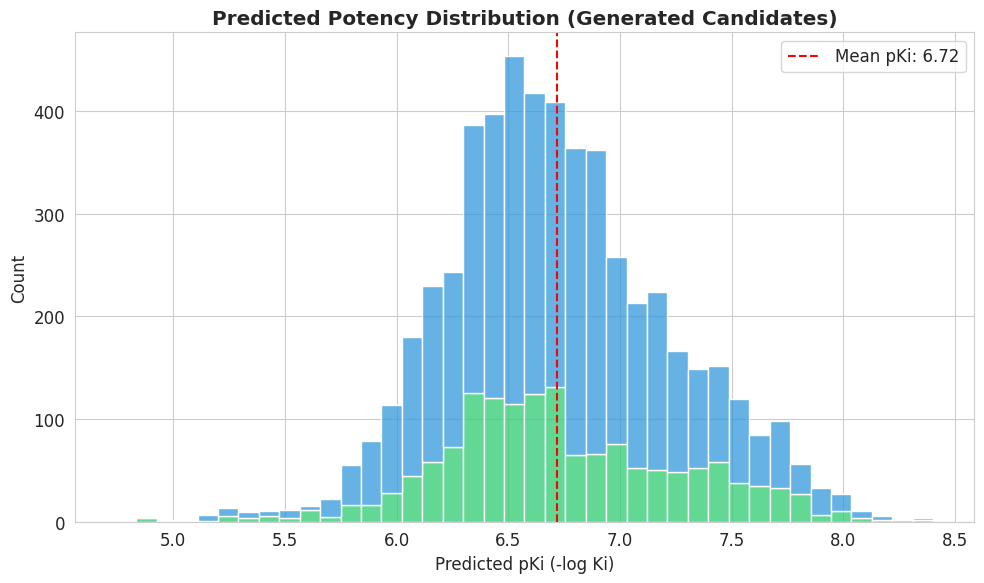

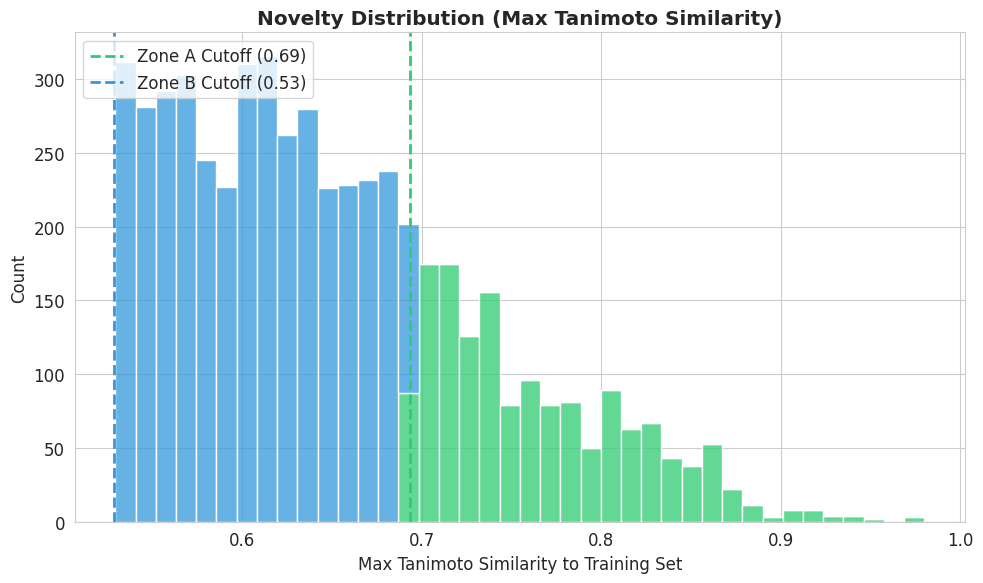

✅ Figures Saved to Project Folder (300 DPI).


In [ ]:
# ==========================================
# 15. VISUALIZATION (MANUSCRIPT FIGURES)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import joblib

print("--- GENERATING PLOTS ---")

# 1. LOAD DATA
full_path = os.path.join(project_folder, "candidates_zoned_full_CNS.csv")
if not os.path.exists(full_path):
    raise FileNotFoundError(f"Could not find {full_path}")

df_viz = pd.read_csv(full_path)
print(f"Loaded {len(df_viz)} candidates for visualization.")

# Load Thresholds for plotting lines
ad_zones = joblib.load(os.path.join(project_folder, 'ad_definition_zones.pkl'))
ZONE_A_TH = ad_zones['zone_definitions']['Zone A (Interpolation)']['threshold']
ZONE_B_TH = ad_zones['zone_definitions']['Zone B (Extrapolation)']['threshold']

# Setup Style
sns.set_style("whitegrid")
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 12})
colors = {"Zone A (Safe)": "#2ecc71", "Zone B (Novel)": "#3498db"} # Green/Blue

# --- PLOT A: pKi DISTRIBUTION ---
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_viz,
    x='Predicted_pKi',
    hue='Zone',
    multiple='stack',
    palette=colors,
    bins=40,
    edgecolor='white'
)
plt.axvline(x=df_viz['Predicted_pKi'].mean(), color='red', linestyle='--', label=f'Mean pKi: {df_viz["Predicted_pKi"].mean():.2f}')
plt.title('Predicted Potency Distribution (Generated Candidates)', fontweight='bold')
plt.xlabel('Predicted pKi (-log Ki)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(project_folder, "Figure_Generative_pKi_Distribution.png"), dpi=300)
plt.show()

# --- PLOT B: TANIMOTO SIMILARITY DISTRIBUTION ---
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_viz,
    x='Max_Sim_AD',
    hue='Zone',
    multiple='stack',
    palette=colors,
    bins=40,
    edgecolor='white'
)
# Add Threshold Lines
plt.axvline(x=ZONE_A_TH, color='#2ecc71', linestyle='--', linewidth=2, label=f'Zone A Cutoff ({ZONE_A_TH:.2f})')
plt.axvline(x=ZONE_B_TH, color='#3498db', linestyle='--', linewidth=2, label=f'Zone B Cutoff ({ZONE_B_TH:.2f})')

plt.title('Novelty Distribution (Max Tanimoto Similarity)', fontweight='bold')
plt.xlabel('Max Tanimoto Similarity to Training Set')
plt.ylabel('Count')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(project_folder, "Figure_Generative_Novelty_Distribution.png"), dpi=300)
plt.show()

print("✅ Figures Saved to Project Folder (300 DPI).")

--- GENERATING PLOTS ---
Loaded 5389 candidates for visualization.


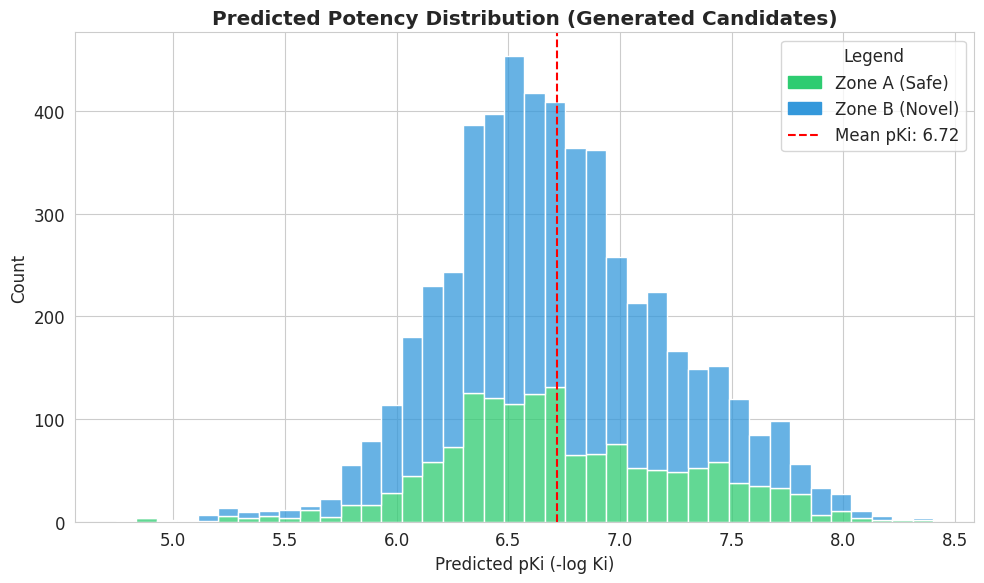

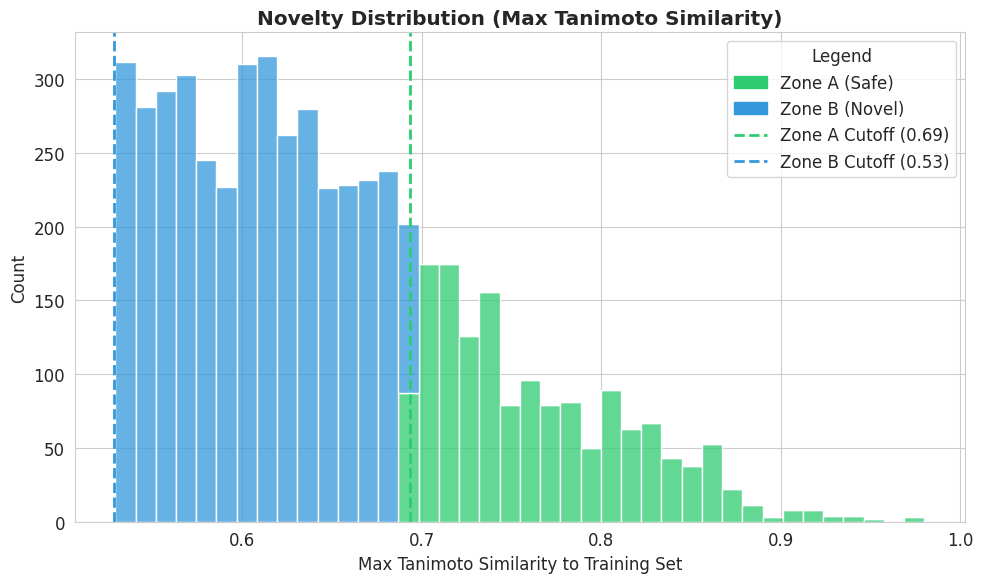

✅ Figures Saved to Project Folder (300 DPI).


In [ ]:
# ==========================================
# 15. VISUALIZATION (MANUSCRIPT FIGURES)
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import pandas as pd
import joblib

print("--- GENERATING PLOTS ---")

# 1. LOAD DATA
full_path = os.path.join(project_folder, "candidates_zoned_full_CNS.csv")
if not os.path.exists(full_path):
    raise FileNotFoundError(f"Could not find {full_path}")

df_viz = pd.read_csv(full_path)
print(f"Loaded {len(df_viz)} candidates for visualization.")

# Load Thresholds
ad_zones = joblib.load(os.path.join(project_folder, 'ad_definition_zones.pkl'))
ZONE_A_TH = ad_zones['zone_definitions']['Zone A (Interpolation)']['threshold']
ZONE_B_TH = ad_zones['zone_definitions']['Zone B (Extrapolation)']['threshold']

# Setup Style
sns.set_style("whitegrid")
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 12})
colors = {"Zone A (Safe)": "#2ecc71", "Zone B (Novel)": "#3498db"}

# Create Manual Legend Handles for Colors
zone_handles = [mpatches.Patch(color=color, label=label) for label, color in colors.items()]

# --- PLOT A: pKi DISTRIBUTION ---
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_viz,
    x='Predicted_pKi',
    hue='Zone',
    multiple='stack',
    palette=colors,
    bins=40,
    edgecolor='white',
    legend=False
)

# Add Mean Line
mean_val = df_viz['Predicted_pKi'].mean()
line_mean = plt.axvline(x=mean_val, color='red', linestyle='--', label=f'Mean pKi: {mean_val:.2f}')

# Legend: Upper Right
plt.legend(handles=zone_handles + [line_mean], loc='upper right', title="Legend")

plt.title('Predicted Potency Distribution (Generated Candidates)', fontweight='bold')
plt.xlabel('Predicted pKi (-log Ki)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(project_folder, "Figure_Generative_pKi_Distribution.png"), dpi=300)
plt.show()

# --- PLOT B: TANIMOTO SIMILARITY DISTRIBUTION ---
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_viz,
    x='Max_Sim_AD',
    hue='Zone',
    multiple='stack',
    palette=colors,
    bins=40,
    edgecolor='white',
    legend=False
)

# Add Threshold Lines
line_a = plt.axvline(x=ZONE_A_TH, color='#2ecc71', linestyle='--', linewidth=2, label=f'Zone A Cutoff ({ZONE_A_TH:.2f})')
line_b = plt.axvline(x=ZONE_B_TH, color='#3498db', linestyle='--', linewidth=2, label=f'Zone B Cutoff ({ZONE_B_TH:.2f})')

# Legend: Upper Right (Moved as requested)
plt.legend(handles=zone_handles + [line_a, line_b], loc='upper right', title="Legend")

plt.title('Novelty Distribution (Max Tanimoto Similarity)', fontweight='bold')
plt.xlabel('Max Tanimoto Similarity to Training Set')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(project_folder, "Figure_Generative_Novelty_Distribution.png"), dpi=300)
plt.show()

print("✅ Figures Saved to Project Folder (300 DPI).")